# ADVANCED CLASSIFICATION: GRADIENT BOOSTING MACHINES SU TITLE TYPE

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedKFold, train_test_split, HalvingGridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score

from xgboost import XGBClassifier

## Reading the data

In [50]:
x_train = (pd.read_csv('data/title type/X_train_title_no_out.csv')).drop('Unnamed: 0', axis =1)
y_train = (pd.read_csv('data/title type/y_train_title_no_out.csv')).drop('Unnamed: 0', axis =1)

x_test = (pd.read_csv('data/title type/X_test_title.csv')).drop('Unnamed: 0', axis =1)
y_test = pd.read_csv('data/title type/y_test_title.csv')

In [51]:
y_train = y_train['title_type']
y_test = y_test['title_type']

In [52]:
folds = StratifiedKFold(n_splits=3, shuffle = True, random_state= 42)

### Log transformation e scaling

In [53]:
cols = ['runtimeMinutes', 'numVotes', 'totalCredits', 'userReviewsTotal', 'totalMedia']

for col in cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])

In [54]:
scaler = StandardScaler()

num_cols = ['startYear', 'runtimeMinutes', 'numVotes', 'totalCredits', 'criticReviewsTotal', 'numRegions', 'userReviewsTotal',
        'companiesNumber', 'averageRating', 'externalLinks', 'writerCredits',
        'directorsCredits', 'quotesTotal', 'totalMedia', 'totalNominations']

scaler.fit(x_train[num_cols])

StandardScaler()

In [55]:
x_train[num_cols] = scaler.transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [56]:
x_train

,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,averageRating,...,genres_Talk-Show,genres_Thriller,genres_War,genres_Western,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America
0,8,1.040471,1.573691,2.563814,0.990223,0.225911,0.521576,3.677701,-0.134297,0.987621,...,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
1,7,0.038105,-0.848664,0.212509,1.367134,-0.227942,0.078359,0.906955,-0.186367,0.090846,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0
2,6,0.318767,1.069687,2.889633,1.884509,1.587468,0.964793,3.718469,1.115396,-0.955392,...,0,0,0,0,0.0,0.0,1.0,1.0,0.0,0.0
3,5,-1.565681,0.947612,0.987327,0.439867,0.074626,0.521576,2.260232,0.021915,-1.104855,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0
4,6,0.358862,1.272139,4.493105,2.727157,17.926160,7.613044,5.352079,4.031347,-0.581736,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101646,8,0.599430,-0.681260,-0.660631,-0.135577,-0.227942,-0.364858,-0.590568,-0.238438,0.912889,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
101647,7,-0.082179,-0.360404,1.179214,0.263207,-0.227942,-0.364858,0.158193,0.126056,0.389771,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
101648,7,1.040471,-0.009896,-0.520087,0.729371,-0.227942,-0.586466,-0.590568,-0.290508,0.240308,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
101649,8,-1.164734,1.830756,-0.286063,-0.655782,-0.227942,-0.364858,-0.590568,-0.186367,0.688696,...,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0


In [57]:
x_test

,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,averageRating,...,genres_Talk-Show,genres_Thriller,genres_War,genres_Western,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America
0,7,-0.803883,0.488189,1.057986,0.960072,-0.076658,2.294443,1.655716,0.021915,-0.282811,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
1,8,0.759808,0.078635,-0.896627,-1.424242,-0.227942,-0.364858,-0.590568,-0.082226,0.539233,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0
2,7,0.479146,0.747215,-1.023017,-1.567537,-0.227942,-0.364858,-0.590568,-0.238438,-0.133348,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0
3,7,0.839998,0.078635,0.044302,1.269926,-0.227942,-0.586466,-0.590568,-0.186367,0.240308,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
4,8,-0.162368,2.310582,-0.791410,-1.300114,-0.227942,-0.364858,-0.590568,-0.290508,0.464502,...,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43895,8,0.238578,-0.488005,0.105500,0.755194,-0.227942,-0.586466,-0.590568,-0.082226,0.539233,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
43896,8,0.398956,0.238896,-1.097201,-3.233113,-0.227942,-0.364858,-0.590568,-0.186367,0.539233,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0
43897,7,0.759808,0.358383,0.031316,0.970232,-0.227942,-0.364858,-0.590568,-0.186367,0.315039,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
43898,6,0.960281,0.134362,-0.841824,1.019427,-0.227942,-0.364858,-0.590568,-0.186367,-0.656467,...,1,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0


### Gaussian NB come baseline

In [58]:
from sklearn.naive_bayes import GaussianNB

In [59]:
dummy = GaussianNB()
dummy.fit(x_train, y_train)

GaussianNB()

In [60]:
y_pred_dummy = dummy.predict(x_test)
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)

print('Il dummy classifier ha raggiunto un accuracy del: ', accuracy_dummy)

Il dummy classifier ha raggiunto un accuracy del:  0.14685649202733486


### Gradient Boosting

In [10]:
gboosting = GradientBoostingClassifier(random_state=42)

gboost_params = {
    'learning_rate': [0.01, 0.1, 1],
    'n_estimators' : [10, 100],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [3, 5, 10],
    'max_depth': [None, 3, 10], 
    'ccp_alpha': [0, 1] 

}

grid_gboost = HalvingGridSearchCV(estimator = gboosting,
                                 param_grid= gboost_params,
                                 cv = folds,
                                 scoring = 'f1_weighted',
                                 factor=2,
                                 resource='n_samples',
                                 min_resources=500,
                                 max_resources='auto',                                 
                                 n_jobs=-1,
                                 verbose=1)


grid_gboost.fit(x_train, y_train)
print('Migliori iperparametri per GradientBoostingMachine:', grid_gboost.best_params_)
print('Miglior score CV per GradientBoostingMachine:', grid_gboost.best_score_)

n_iterations: 8
n_required_iterations: 9
n_possible_iterations: 8
min_resources_: 500
max_resources_: 101651
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 324
n_resources: 500
Fitting 3 folds for each of 324 candidates, totalling 972 fits
----------
iter: 1
n_candidates: 162
n_resources: 1000
Fitting 3 folds for each of 162 candidates, totalling 486 fits
----------
iter: 2
n_candidates: 81
n_resources: 2000
Fitting 3 folds for each of 81 candidates, totalling 243 fits
----------
iter: 3
n_candidates: 41
n_resources: 4000
Fitting 3 folds for each of 41 candidates, totalling 123 fits
----------
iter: 4
n_candidates: 21
n_resources: 8000
Fitting 3 folds for each of 21 candidates, totalling 63 fits
----------
iter: 5
n_candidates: 11
n_resources: 16000
Fitting 3 folds for each of 11 candidates, totalling 33 fits


/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 6
n_candidates: 6
n_resources: 32000
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 7
n_candidates: 3
n_resources: 64000
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Migliori iperparametri per GradientBoostingMachine: {'ccp_alpha': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Miglior score CV per GradientBoostingMachine: 0.9089659060545414


In [61]:
gb_model = grid_gboost.best_estimator_
#gb_model.fit(x_train, y_train)

Predizione sul test set e confronto con training set

In [62]:
y_train_pred_gb = gb_model.predict(x_train)
print('Classification Report per Gradient Boosting Classifier - Training Set')
print(classification_report(y_train, y_train_pred_gb))
print(f'Accuracy del GBClassifier sul train set: {accuracy_score(y_train, y_train_pred_gb)}')
print(f'F1 Score del GBClassifier sul train set: {f1_score(y_train, y_train_pred_gb, average="weighted")}')

Classification Report per Gradient Boosting Classifier - Training Set
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     24348
           1       1.00      1.00      1.00     11452
           2       1.00      1.00      1.00     49104
           3       0.99      1.00      0.99      1080
           4       0.98      0.97      0.98      4090
           5       1.00      0.99      0.99      6056
           6       0.93      0.99      0.96       187
           7       1.00      1.00      1.00       717
           8       0.99      0.97      0.98      3469
           9       1.00      1.00      1.00      1148

    accuracy                           1.00    101651
   macro avg       0.99      0.99      0.99    101651
weighted avg       1.00      1.00      1.00    101651

Accuracy del GBClassifier sul train set: 0.9952779608661007
F1 Score del GBClassifier sul train set: 0.9952687612788621


In [63]:
y_pred_gb = gb_model.predict(x_test)
y_gb_proba = gb_model.predict_proba(x_test)
print('Classification Report per Gradient Boosting Classifier - Test Set')
print(classification_report(y_test, y_pred_gb))
print(f'Accuracy del GBClassifier sul test set: {accuracy_score(y_test, y_pred_gb)}')
print(f'F1 Score del GBClassifier sul test set: {f1_score(y_test, y_pred_gb, average="weighted")}')

Classification Report per Gradient Boosting Classifier - Test Set
              precision    recall  f1-score   support

           0       0.90      0.95      0.93     10672
           1       0.94      0.95      0.94      4913
           2       0.98      0.98      0.98     21063
           3       0.53      0.38      0.44       467
           4       0.66      0.49      0.56      1755
           5       0.86      0.91      0.89      2647
           6       0.09      0.20      0.12        81
           7       0.56      0.39      0.46       311
           8       0.71      0.56      0.63      1494
           9       0.89      0.73      0.80       497

    accuracy                           0.92     43900
   macro avg       0.71      0.65      0.67     43900
weighted avg       0.91      0.92      0.92     43900

Accuracy del GBClassifier sul test set: 0.9184738041002278
F1 Score del GBClassifier sul test set: 0.9150074194974744


In [17]:
mapping = {
     'movie': np.int64(0),
     'short': np.int64(1),
     'tvEpisode': np.int64(2),
     'tvMiniSeries': np.int64(3),
     'tvMovie': np.int64(4),
     'tvSeries': np.int64(5),
     'tvShort': np.int64(6),
     'tvSpecial': np.int64(7),
     'video': np.int64(8),
     'videoGame': np.int64(9)
 }

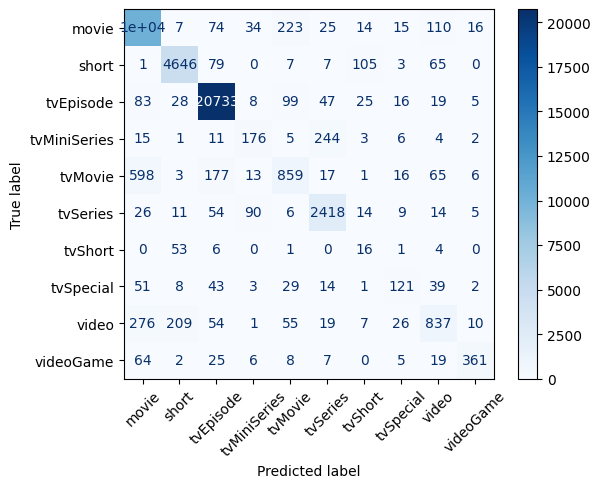

In [ ]:
y_true_mapped = np.array(y_test, dtype=int)
y_pred_mapped = np.array(y_pred_gb, dtype=int)


labels_sorted = sorted(mapping, key=mapping.get)  # ordina le stringhe in base al numero

cm = confusion_matrix(y_true_mapped, y_pred_mapped, labels=range(len(mapping)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

In [73]:
from sklearn.preprocessing import label_binarize
import seaborn as sns
from itertools import cycle
import matplotlib.cm as mpl_cm

/var/folders/32/wr6jfczj32q0c3fcn7fkrtvr0000gn/T/ipykernel_834/92740147.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = mpl_cm.get_cmap('tab10', n_classes).colors


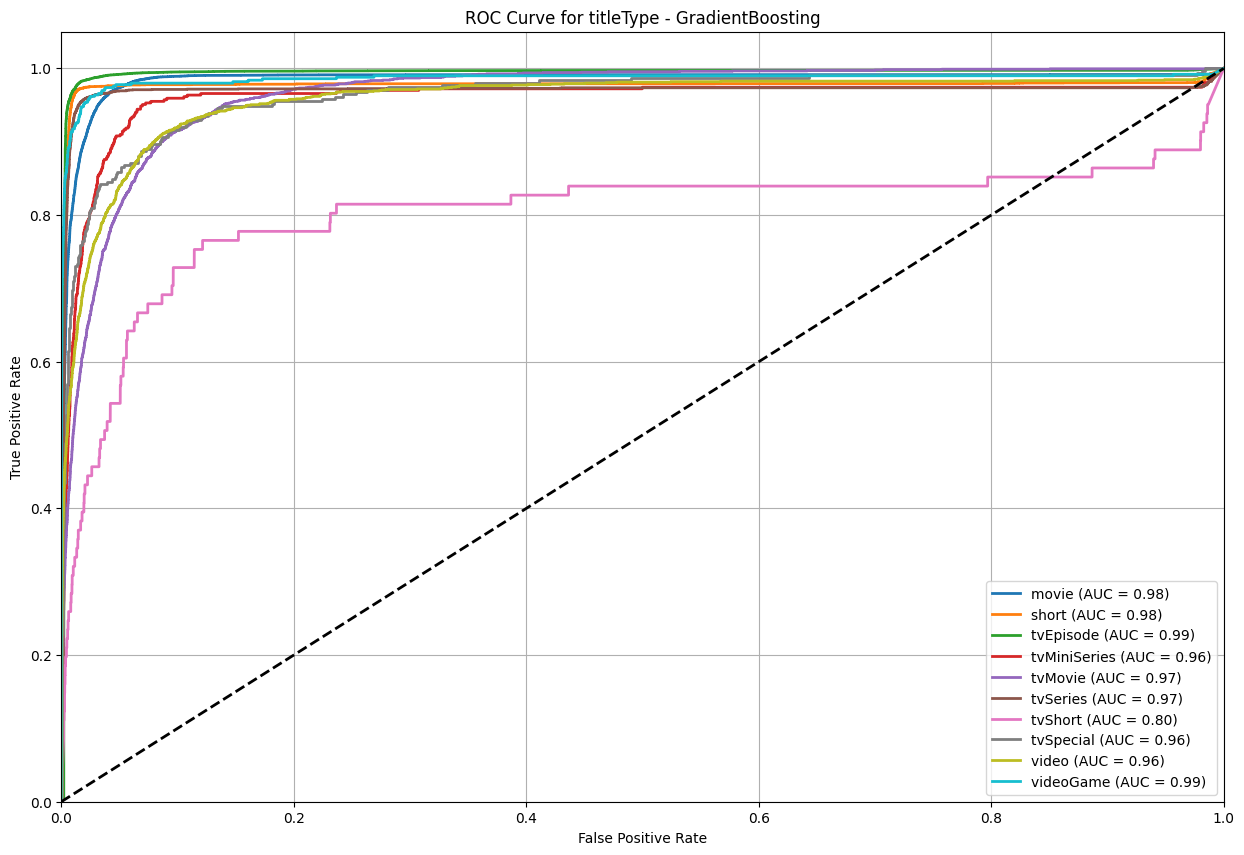

In [74]:
class_names = ['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 'tvSeries', 'tvShort', 'tvSpecial', 'video', 'videoGame']

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(15,10))
colors = mpl_cm.get_cmap('tab10', n_classes).colors
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_gb_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for titleType - GradientBoosting')
plt.legend(loc='lower right')
plt.grid()
plt.show()

### XGBoost

In [75]:
from xgboost import XGBClassifier

In [108]:
xgb = XGBClassifier(random_state = 42)

xgboost_params = {
    'alpha' : [0.01, 0.1, 1],
    'booster' : ['gbtree', 'dart'],
    'colsample_bytree' : [0.8, 1],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [10, 30, 50]
}

In [123]:
grid_xgb = HalvingGridSearchCV(estimator = xgb,
                               param_grid = xgboost_params,
                               cv = folds, 
                               scoring = 'f1_weighted',
                               factor=2,
                               resource='n_samples',
                               min_resources=600, 
                               max_resources='auto',                               
                               n_jobs = -1, 
                               verbose = 1)

In [125]:
grid_xgb.fit(x_train, y_train)
print('Migliori iperparametri per XGBoost:', grid_xgb.best_params_)
print('Miglior score CV per XGBoost:', grid_xgb.best_score_)

n_iterations: 8
n_required_iterations: 8
n_possible_iterations: 8
min_resources_: 600
max_resources_: 101651
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 216
n_resources: 600
Fitting 3 folds for each of 216 candidates, totalling 648 fits


/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
216 fits failed out of a total of 648.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
216 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/xgboost/core.py", line 729, in inner_f
    return func(**kwargs)
  File "/Users/laviniarotellini/Desktop/DM2/.venv/lib/pyt

----------
iter: 1
n_candidates: 108
n_resources: 1200
Fitting 3 folds for each of 108 candidates, totalling 324 fits


/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan  

----------
iter: 2
n_candidates: 54
n_resources: 2400
Fitting 3 folds for each of 54 candidates, totalling 162 fits


...

----------
iter: 6
n_candidates: 4
n_resources: 38400
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan  

----------
iter: 7
n_candidates: 2
n_resources: 76800
Fitting 3 folds for each of 2 candidates, totalling 6 fits


/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan  

Migliori iperparametri per XGBoost: {'alpha': 0.01, 'booster': 'gbtree', 'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 50}
Miglior score CV per XGBoost: 0.9069221202004308


In [126]:
xgb_model = XGBClassifier(**grid_xgb.best_params_, random_state = 42)
xgb_model.fit(x_train, y_train)

XGBClassifier(alpha=0.01, base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None, ...)

Predizione sul test set e confronto con training set

In [127]:
y_train_pred_xgb = xgb_model.predict(x_train)
print('Classification Report per XGBoost - Training Set')
print(classification_report(y_train, y_train_pred_xgb))
print(f'Accuracy di XGBoost sul train set: {accuracy_score(y_train, y_train_pred_xgb)}')
print(f'F1 Score del XGBoost sul train set: {f1_score(y_train, y_train_pred_xgb, average="weighted")}')

Classification Report per XGBoost - Training Set
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     24348
           1       0.96      0.99      0.97     11452
           2       0.98      0.99      0.99     49104
           3       0.90      0.64      0.75      1080
           4       0.81      0.48      0.60      4090
           5       0.91      0.98      0.94      6056
           6       1.00      0.49      0.65       187
           7       0.88      0.68      0.77       717
           8       0.90      0.63      0.74      3469
           9       0.98      0.93      0.95      1148

    accuracy                           0.95    101651
   macro avg       0.92      0.78      0.83    101651
weighted avg       0.94      0.95      0.94    101651

Accuracy di XGBoost sul train set: 0.9467098208576403
F1 Score del XGBoost sul train set: 0.9421915940100162


In [128]:
y_pred_xgb = xgb_model.predict(x_test)
y_xgb_proba = xgb_model.predict_proba(x_test)
print('Classification Report per XGBoost - Test Set')
print(classification_report(y_test, y_pred_xgb))
print(f'Accuracy di XGBoost sul test set: {accuracy_score(y_test, y_pred_xgb)}')
print(f'F1 Score i XGBoost sul test set: {f1_score(y_test, y_pred_xgb, average="weighted")}')

Classification Report per XGBoost - Test Set
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     10672
           1       0.93      0.97      0.95      4913
           2       0.97      0.99      0.98     21063
           3       0.64      0.36      0.46       467
           4       0.67      0.36      0.47      1755
           5       0.87      0.95      0.91      2647
           6       0.89      0.10      0.18        81
           7       0.64      0.41      0.50       311
           8       0.78      0.50      0.61      1494
           9       0.91      0.73      0.81       497

    accuracy                           0.92     43900
   macro avg       0.82      0.63      0.68     43900
weighted avg       0.91      0.92      0.91     43900

Accuracy di XGBoost sul test set: 0.9207744874715262
F1 Score i XGBoost sul test set: 0.912012498440093


In [130]:
y_pred_mapped_xgb = np.array(y_pred_xgb, dtype=int)

labels = list(mapping.keys())
labels_sorted = sorted(mapping, key=mapping.get) 

cm = confusion_matrix(y_true_mapped, y_pred_mapped_xgb, labels=range(len(mapping)))
disp = ConfusionMatrixDisplay(cm)

/var/folders/32/wr6jfczj32q0c3fcn7fkrtvr0000gn/T/ipykernel_834/1818748227.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = mpl_cm.get_cmap('tab10', n_classes).colors


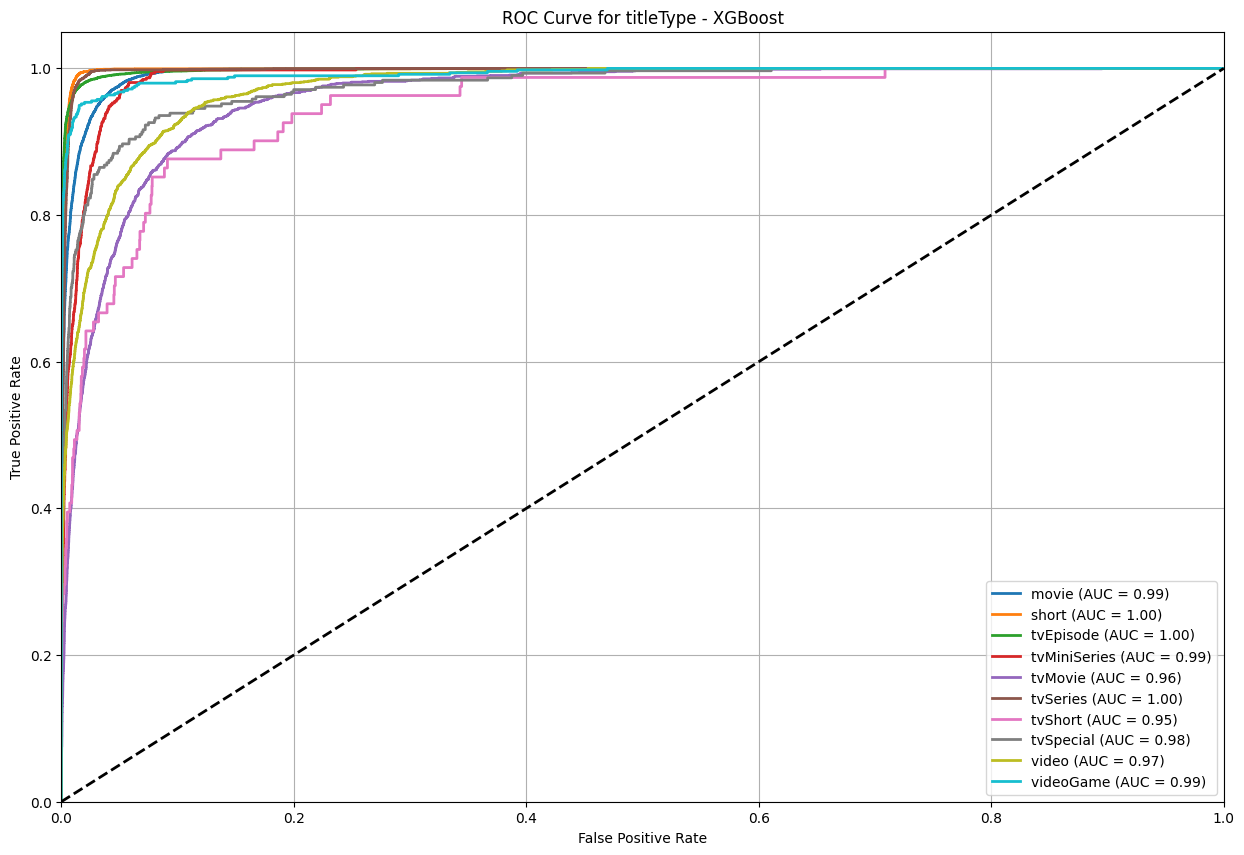

In [132]:
plt.figure(figsize=(15,10))
colors = mpl_cm.get_cmap('tab10', n_classes).colors
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_xgb_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for titleType - XGBoost')
plt.legend(loc='lower right')
plt.grid()
plt.show()

### Salvataggio modelli

In [133]:
model_path = "/Applications/OneDrive.app"
import joblib

In [134]:
joblib.dump(
   gb_model,
    model_path + 'gb_dm2_titletype'+ '.pkl'
)

['/Applications/OneDrive.appgb_dm2_titletype.pkl']

In [ ]:
joblib.dump(
   xgb_model,
    model_path + 'xgb_dm2_titletype'+ '.pkl'
)